In [1]:
import fitsio, re
from numpy.typing import NDArray, DTypeLike
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

import euclidlib as el

from cloelike import EuclidLikelihood_3x2pt_Cls
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower
from cloelike import EuclidLikelihood_GCSpectro_Pks
from astropy.io import fits

/Users/pedro/miniconda3/envs/cloelite/lib/python3.9/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/pedro/miniconda3/envs/cloelite/lib/python3.9/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# Get n(z)

z_nz, nz_heracles = el.photo.redshift_distributions('../cloe_playground/tutorials/observables/nz_example.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z_nz)


# Resampling the normalized n(z) with 100 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_nz, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_she_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(myz, z_nz, my_dndz_she[i,:])

In [3]:
cells_data = el.photo.angular_power_spectra('../cloe_playground/tutorials/observables/cls_example.fits')
mixmat = el.photo.mixing_matrices('../cloe_playground/tutorials/observables/mixmats_example.fits')

In [4]:
# Made up Gaussian Covariance without any mixing matrix or anything
full_cov=np.load('cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_Bmode_copy.npy')

In [5]:
redshifts = [1.0, 1.2, 1.4, 1.65]
labels = [str(z).strip('0') for z in redshifts]

data = {
    'GCspectro': {},
    'fiducial_cosmology': {
        'H0': 67.0,
        'Omega_cdm0': 0.27,
        'Omega_b0': 0.049,
        'Omega_k0': 0.0,
        'w0': -1.0,
        'wa': 0.0,
        'ns': 0.96,
        'mnu':0.06,
        'As': 2.1e-9,
        'gamma_MG': 0.545
    }
}

fid_h = data['fiducial_cosmology']['H0'] / 100.0

def get_index(multipole, scale, scale_dict):
    offset = sum(len(scale_dict[ell]) for ell in multipoles if ell < multipole)
    return offset + np.where(scale_dict[multipole] == scale)[0][0]

k_fac = fid_h
pk_fac = 1.0 / fid_h**3
cov_fac = 1.0 / fid_h**6

nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03])* fid_h**3

for ii,z in enumerate(labels):

    data['GCspectro'][z] = {}
    
    filename = f'/Users/pedro/Documents/GitHub/cloelike/test_data/cov_power_galaxies_EFT_benchmark_z{z}.fits'
    hdul = fits.open(filename)
    average = hdul['AVERAGE'].data
    data['GCspectro'][z]['k'] = average['SCALE_1DIM'] * k_fac
    data['GCspectro'][z]['pk0'] = average['AVERAGE0'] * pk_fac
    data['GCspectro'][z]['pk2'] = average['AVERAGE2'] * pk_fac
    data['GCspectro'][z]['pk4'] = average['AVERAGE4'] * pk_fac

    
    covariance = hdul['COVARIANCE'].data
    scale_i = covariance["SCALE_1DIM-I"]
    multipole_i = covariance["MULTIPOLE-I"]
    scale_j = covariance["SCALE_1DIM-J"]
    multipole_j = covariance["MULTIPOLE-J"]
    covariance = covariance["COVARIANCE"]

    multipoles = np.array([0, 2, 4])
    scale_dict = {ell: np.unique(scale_i[multipole_i == ell]) for ell in multipoles}
    matrix_size = sum(len(scale_dict[ell]) for ell in multipoles)
    cov_matrix = np.zeros((matrix_size, matrix_size))
    for s_i, m_i, s_j, m_j, cov in zip(scale_i, multipole_i, scale_j, multipole_j, covariance):
        i = get_index(m_i, s_i, scale_dict)
        j = get_index(m_j, s_j, scale_dict)
        cov_matrix[i, j] = cov
    data['GCspectro'][z]['cov'] = cov_matrix

    data['GCspectro'][z]['nbar'] = nbar[ii]



In [6]:
settings = {
    'scale_cuts': {
        'GCspectro': {
            'bin1': {
                'ell0': [0.0, 0.20], 'ell2': [0.0, 0.15], 'ell4': [0.0, 0.15]
            },
            'bin2': {
                'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]
            },
            'bin3': {
                'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]
            },
            'bin4': {
                'ell0': [0.0, 0.30], 'ell2': [0.0, 0.25], 'ell4': [0.0, 0.25]
            }
        }
    }
}

settings = {
    'scale_cuts': {
        'GCspectro': {
            bin_key: {
                ell_key: [v * fid_h for v in values]
                for ell_key, values in bin_values.items()
            }
            for bin_key, bin_values in settings['scale_cuts']['GCspectro'].items()
        }
    }
}

In [7]:
# Scale cuts have the same format as the data
scale_cut_dict = dict.fromkeys(cells_data.keys(), [10,1500])

for key in cells_data.keys():
    if key[:2]==('SHE','SHE'):
        scale_cut_dict[key]=[scale_cut_dict[key],[0,0]]

In [8]:
data_dict = {'cells':cells_data,'ells':cells_data['POS', 'POS', 1, 1].ell,
             'z_arr':myz,'dndz_pos':my_dndz_pos_norm,'dndz_she':my_dndz_she_norm,
             'cov':full_cov,'mixmat':mixmat}

settings_dict = {'n_ell_bins':32,'scale_cuts':scale_cut_dict}

like_test_photo = EuclidLikelihood_3x2pt_Cls.EuclidLikelihood3x2ptCls(data_dict,settings_dict,
                                                                CAMBBackground,HMemuLinearPerturbations, HMemuNonLinearPerturbations)

In [9]:
like_test_spectro = EuclidLikelihood_GCSpectro_Pks.EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower)


In [10]:
default_pars = {'H0':67,'Omega_cdm0':0.25,'Omega_b0':0.05,'ns':0.965,'As':2.1e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.06,'gamma_MG':0.545,
                'log10TAGN': 7.8,
                'AIA':1.72, 'EtaIA':-0.41,
                'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0, 
                'b1_photo_poly2': 0, 'b1_photo_poly3': 0,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
                'b1': [1.412, 1.769, 2.039, 2.496],
                'b2': [0.695, 0.870, 1.162, 2.010],
                'bG2': [-0.156, -0.299, -0.400, -0.555],
                'bGam3': [0.323, 0.621, 0.827, 1.137],
                'c0': [30.948, 37.116, 36.738, 53.627],
                'c2': [46.233, 53.071, 48.626, 60.962],
                'c4': [10.057, 10.385, 8.643, 8.711],
                'cnlo': [0.0, 0.0, 0.0, 0.0],
                'NP0': [1.056, 1.152, 1.144, 1.309],
                'NP20': [0.0, 0.0, 0.0, 0.0],
                'NP22': [0.0, 0.0, 0.0, 0.0],
                'fout': [0.195, 0.204, 0.306, 0.121],
                'sigmaz': [0.002, 0.002, 0.002, 0.002]}

In [11]:
%time like_test_photo.loglike(default_pars)

CPU times: user 11.5 s, sys: 2.34 s, total: 13.8 s
Wall time: 11.2 s


-124.7818375711701

In [12]:
%time like_test_spectro.loglike(default_pars)

CPU times: user 1.83 s, sys: 1.56 s, total: 3.39 s
Wall time: 645 ms


-281772.6628556155

In [13]:
%%time

Oc_arr = np.linspace(0.23,0.28,100)
like_arr_photo=[]
like_arr_spectro=[]
like_arr_photo_spectro=[]
for Oc in Oc_arr:
    pars_vary = default_pars.copy()
    pars_vary['Omega_cdm0'] = Oc
    
    like_arr_photo.append(like_test_photo.loglike(pars_vary))
    like_arr_spectro.append(like_test_spectro.loglike(pars_vary))
    like_arr_photo_spectro.append(like_test_photo.loglike(pars_vary)+like_test_spectro.loglike(pars_vary))

like_arr_photo =np.asarray(like_arr_photo)
like_arr_spectro =np.asarray(like_arr_spectro)
like_arr_photo_spectro =np.asarray(like_arr_photo_spectro)

CPU times: user 6min 26s, sys: 9min 1s, total: 15min 27s
Wall time: 2min 20s


Text(0.5, 0, '$\\Omega_c$')

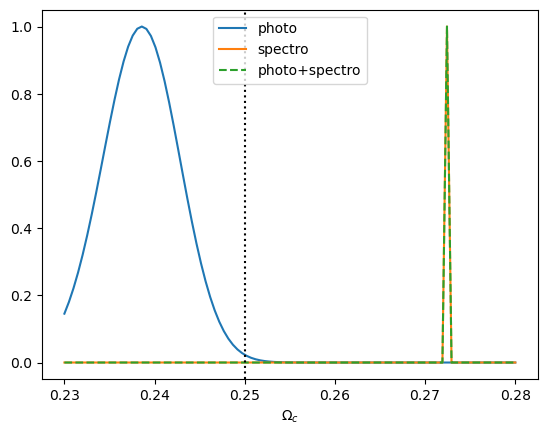

In [14]:
plt.plot(Oc_arr,np.exp(like_arr_photo-np.max(like_arr_photo)),label='photo')
plt.plot(Oc_arr,np.exp(like_arr_spectro-np.max(like_arr_spectro)),label='spectro')
plt.plot(Oc_arr,np.exp(like_arr_photo_spectro-np.max(like_arr_photo_spectro)),'--',label='photo+spectro')
plt.axvline(0.25,ls=':',c='k')
plt.legend()
plt.xlabel(r'$\Omega_c$')

In [27]:
from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
prior = Prior()
#prior.add_parameter('ombh2', dist=norm(loc=0.0227, scale=0.00038))
prior.add_parameter('omch2', dist=(0.11, 0.13))
prior.add_parameter('logAs', dist=(np.log(1.7e-9*1e10), np.log(2.5e-9*1e10)))
#prior.add_parameter('ns', dist=(0.6, 1.2))
#prior.add_parameter('H0', dist=(50, 90))
#prior.add_parameter('AIA', dist=(-1, 1))
#prior.add_parameter('EtaIA', dist=(-5, 5))


def like_Naut_test(param_dict):

    pars_in = default_pars.copy()

    pars_in.update(param_dict)

    pars_in['Omega_cdm0'] = param_dict['omch2'] / (pars_in['H0']/100)**2
    pars_in['As'] = np.exp(param_dict['logAs'])*1e-10
    
    try:
        like = like_test_photo.loglike(pars_in)+like_test_spectro.loglike(pars_in)
    except ValueError:
        like = -np.inf
    
    return like

In [28]:
sampler = Sampler(prior, like_Naut_test, n_live=100)

In [29]:
sampler.run(verbose=True,n_eff=2000)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 21     | 1        | 4        | 4100     | N/A    | 2110  | -679.22  


True

In [30]:
points, log_w, log_l = sampler.posterior()
np.savez_compressed("/Users/pedro/Documents/GitHub/cloelike/Naut_chain_2par_3x2_Spectro_test",
                    chain = points, weights=log_w, logl = log_l)